<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/AU_v1_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import numpy as np
import pandas as pd

# 1. Prompt file upload in Colab
print("Please upload 'AU-PEMal-2025-V1.csv':")
uploaded = files.upload()

input_file = "AU-PEMal-2025-V1.csv"
output_file = "AU-PEMal-2025-V1_Cleaned.csv"

# 2. Load raw dataset
df = pd.read_csv(input_file)
print(f"Initial Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 3. Drop non-predictive hash column ('sha1')
if "sha1" in df.columns:
    df = df.drop(columns=["sha1"])
    print("Dropped non-predictive hash column: 'sha1'")

# 4. Convert PE Header Hexadecimal columns ('0x...') to numeric integers
hex_cols = [
    "EntryPoint",
    "SizeOfCode",
    "SizeOfImage",
    "SizeOfInitializedData",
    "SizeOfUninitializedData",
    "rdata_VirtualSize",
    "rdata_VirtualAddress",
    "rdata_SizeOfRawData",
    "rdata_PointerToRawData",
    "text_VirtualSize",
    "text_SizeOfRawData",
    "text_PointerToRawData",
    "BaseOfCode",
    "BaseOfData",
    "ImageBase",
    "Checksum",
    "SectionAlignment",
    "SizeOfHeaders",
]


def parse_hex_to_int(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip()
    try:
        if val_str.startswith("0x") or val_str.startswith("0X"):
            return int(val_str, 16)
        else:
            return int(float(val_str))
    except Exception:
        return 0


for col in hex_cols:
    if col in df.columns:
        df[col] = df[col].apply(parse_hex_to_int)

print(
    f"Successfully converted {len(hex_cols)} PE header hex features to standard integers."
)

# 5. Drop duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Dropping {duplicate_count} duplicate feature rows...")
df_cleaned = df.drop_duplicates(keep="first")

# 6. Check for zero-variance constant columns
constant_cols = [
    c for c in df_cleaned.columns if df_cleaned[c].nunique() <= 1
]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    df_cleaned = df_cleaned.drop(columns=constant_cols)

print(
    f"Final Cleaned Shape: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns"
)

# 7. Save and trigger automatic download
df_cleaned.to_csv(output_file, index=False)
print("Downloading cleaned dataset...")
files.download(output_file)

Please upload 'AU-PEMal-2025-V1.csv':


Saving AU-PEMal-2025-V1.csv to AU-PEMal-2025-V1.csv
Initial Dataset Shape: 21703 rows, 39 columns
Dropped non-predictive hash column: 'sha1'
Successfully converted 18 PE header hex features to standard integers.
Dropping 129 duplicate feature rows...
Final Cleaned Shape: 21574 rows, 38 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'AU-PEMal-2025-V1_Cleaned.csv' not found. Checking for raw dataset...
Please upload 'AU-PEMal-2025-V1.csv':


Saving AU-PEMal-2025-V1.csv to AU-PEMal-2025-V1.csv
Cleaning 'AU-PEMal-2025-V1.csv'...
Saved 'AU-PEMal-2025-V1_Cleaned.csv' (21574 rows, 38 columns).
Dataset loaded: 21574 rows, 38 columns.

================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

  Agenttesla     1.0000    1.0000    1.0000        67
      Benign     0.9930    0.9949    0.9940      2154
      Cerber     0.9701    0.9848    0.9774        66
    DarkSide     1.0000    0.9851    0.9925        67
      Dharma     1.0000    0.9505    0.9746       101
      Emotet     0.9571    0.9710    0.9640        69
    Formbook     0.9490    0.9894    0.9688        94
    Gandcrab     0.9706    0.9706    0.9706        68
       Gh0st     0.9630    0.8764    0.9176        89
    Glupteba     0.9565    0.9565    0.9565        69
    Guloader     0.9551    0.9659    0.9605        88
     LockBit     0.9462    1.0000    0.9724        88
        Maze     1.0000    1.0000    1.0000       

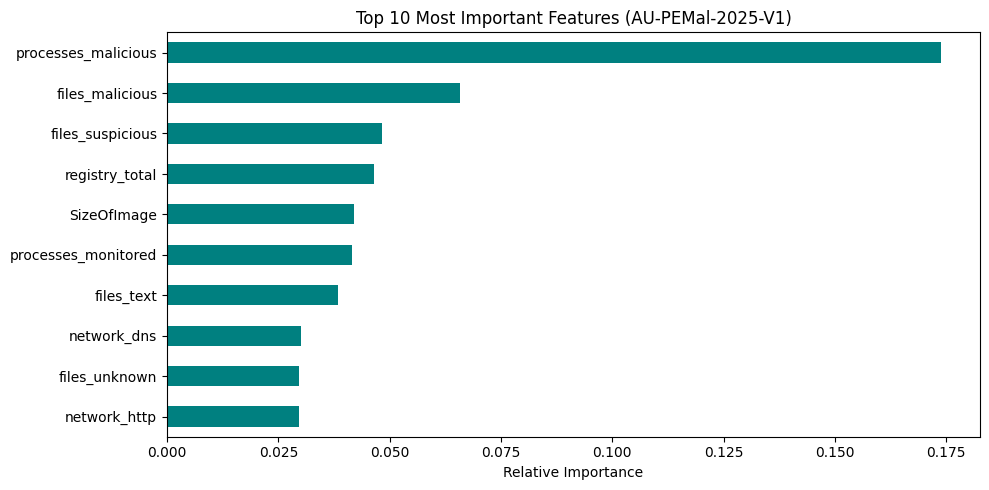

In [2]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

cleaned_file = "AU-PEMal-2025-V1_Cleaned.csv"

# 1. Check if cleaned dataset exists; if not, look for raw file or prompt upload
if not os.path.exists(cleaned_file):
    print(f"'{cleaned_file}' not found. Checking for raw dataset...")
    raw_files = [
        f for f in glob.glob("AU-PEMal-2025-V1*.csv") if "Cleaned" not in f
    ]

    if raw_files:
        raw_file = raw_files[0]
        print(f"Found existing raw file: '{raw_file}'")
    else:
        print("Please upload 'AU-PEMal-2025-V1.csv':")
        uploaded = files.upload()
        raw_file = list(uploaded.keys())[0]

    # Preprocess and clean raw dataset
    print(f"Cleaning '{raw_file}'...")
    df_raw = pd.read_csv(raw_file)

    if "sha1" in df_raw.columns:
        df_raw = df_raw.drop(columns=["sha1"])

    hex_cols = [
        "EntryPoint",
        "SizeOfCode",
        "SizeOfImage",
        "SizeOfInitializedData",
        "SizeOfUninitializedData",
        "rdata_VirtualSize",
        "rdata_VirtualAddress",
        "rdata_SizeOfRawData",
        "rdata_PointerToRawData",
        "text_VirtualSize",
        "text_SizeOfRawData",
        "text_PointerToRawData",
        "BaseOfCode",
        "BaseOfData",
        "ImageBase",
        "Checksum",
        "SectionAlignment",
        "SizeOfHeaders",
    ]

    def parse_hex_to_int(val):
        if pd.isna(val):
            return 0
        val_str = str(val).strip()
        try:
            if val_str.startswith("0x") or val_str.startswith("0X"):
                return int(val_str, 16)
            else:
                return int(float(val_str))
        except Exception:
            return 0

    for col in hex_cols:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].apply(parse_hex_to_int)

    df_clean = df_raw.drop_duplicates(keep="first")
    df_clean.to_csv(cleaned_file, index=False)
    print(
        f"Saved '{cleaned_file}' ({df_clean.shape[0]} rows, {df_clean.shape[1]} columns)."
    )

# 2. Load the cleaned dataset
df = pd.read_csv(cleaned_file)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

# 3. Select Target (Family multi-class) and Features
target_col = "Family"  # Options: 'Class', 'Category', 'Family'

le = LabelEncoder()
y = le.fit_transform(df[target_col])

# Drop target label columns from feature matrix X
X = df.drop(columns=["Class", "Category", "Family"])

# 4. Stratified Train / Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 6. Evaluate Performance
y_pred = model.predict(X_test)
class_names = le.classes_

print("\n================ CLASSIFICATION REPORT ================")
print(
    classification_report(y_test, y_pred, target_names=class_names, digits=4)
)

# 7. Plot & Save Top 10 Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

plt.figure(figsize=(10, 5))
top_10.plot(kind="barh", color="teal")
plt.title("Top 10 Most Important Features (AU-PEMal-2025-V1)")
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("v1_feature_importance.png", dpi=300)
plt.show()